In [ ]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[1]
sys.path.append(str(PROJECT_ROOT / "DUALTEST"))

In [2]:
from run_experiment import run_experiment

df = run_experiment(
    dataset_name="booktection",
    target_model_name="Qwen/Qwen2.5-1.5B",
    reference_model_name="Qwen/Qwen2.5-0.5B",
    n=100,
    random_state=7,
    balance_labels=True,
    prefix_len=64,
    continuation_len=64,
    max_new_tokens=64,
    output_name="booktection_qwen15_qwen05_n100.csv",
)
df.head()

/home/alumno1/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
Dataset: booktection
Target: Qwen/Qwen2.5-1.5B
Reference: Qwen/Qwen2.5-0.5B
Registros cargados: 100


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
100%|██████████| 100/100 [00:50<00:00,  1.96it/s]

Guardado en: /home/alumno1/Desktop/NLP_Proyecto_Final-main/results/booktection_qwen15_qwen05_n100.csv

Resumen:
       run_length  edit_similarity     p_rlb         p_esb
label                                                     
0            0.70         0.257213  0.725848  7.664627e-08
1            0.76         0.257800  0.629915  3.273240e-13


,id,dataset,label,membership,run_length,p_rlb,edit_similarity,p_esb,prefix,ground_truth,target_completion,target_model,reference_model
0,booktection_11845_A.txt,booktection,0,non_member,0,1.000000,0.220472,0.000000e+00,"William Christian Bullitt Jr., the United Stat...",seemed always scrunched in a perpetual frown....,hid his expression. He was a man of few words...,Qwen/Qwen2.5-1.5B,Qwen/Qwen2.5-0.5B
1,booktection_10705_A.txt,booktection,0,non_member,0,1.000000,0.179054,9.820316e-32,Echo was staggered by the savage spectacle and...,threw her with ease. It was Echos first fight...,was able to hold her up. Cho then turned her ...,Qwen/Qwen2.5-1.5B,Qwen/Qwen2.5-0.5B
2,booktection_05340_A.txt,booktection,1,member,0,1.000000,0.299094,1.162015e-28,This was a most unpleasant thought for Grenoui...,sparingly with it? And then? He saw himself s...,"carefully. But then, if he perfumed himself v...",Qwen/Qwen2.5-1.5B,Qwen/Qwen2.5-0.5B
3,booktection_04724_A.txt,booktection,1,member,1,0.176398,0.328358,0.000000e+00,"He, Harry, had broken Wizard law just like Sir...",had spent two months there only last year. Ha...,"had told him about it, but he’d only mentione...",Qwen/Qwen2.5-1.5B,Qwen/Qwen2.5-0.5B
4,booktection_12201_A.txt,booktection,0,non_member,0,1.000000,0.263830,3.847945e-20,I’d like to slice off this Prue McCullen’s pla...,cheap and unsuitable for her age but I presum...,a white T-shirt and a black jacket. She’s not...,Qwen/Qwen2.5-1.5B,Qwen/Qwen2.5-0.5B


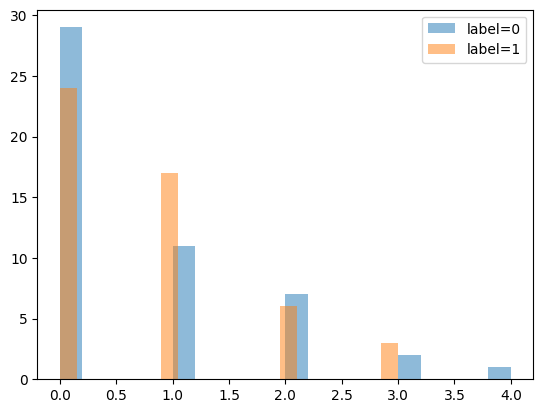

In [3]:
import matplotlib.pyplot as plt

for label in [0,1]:
    subset = df[df.label == label]

    plt.hist(
        subset["run_length"],
        bins=20,
        alpha=0.5,
        label=f"label={label}"
    )

plt.legend()
plt.show()

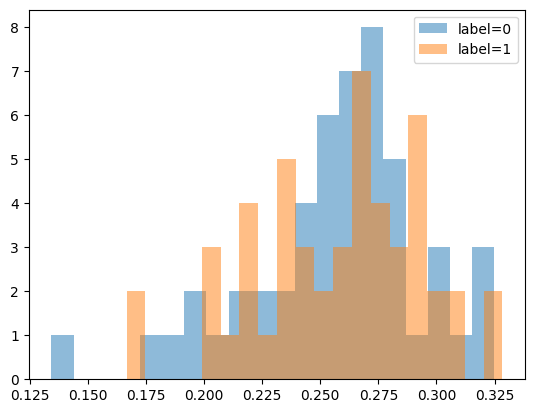

In [4]:
import matplotlib.pyplot as plt

for label in [0,1]:
    subset = df[df.label == label]

    plt.hist(
        subset["edit_similarity"],
        bins=20,
        alpha=0.5,
        label=f"label={label}"
    )

plt.legend()
plt.show()

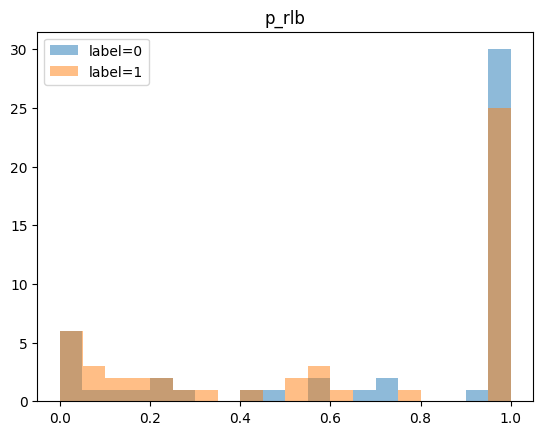

In [5]:
for label in [0,1]:
    subset = df[df.label == label]

    plt.hist(
        subset["p_rlb"],
        bins=20,
        alpha=0.5,
        label=f"label={label}"
    )

plt.legend()
plt.title("p_rlb")
plt.show()

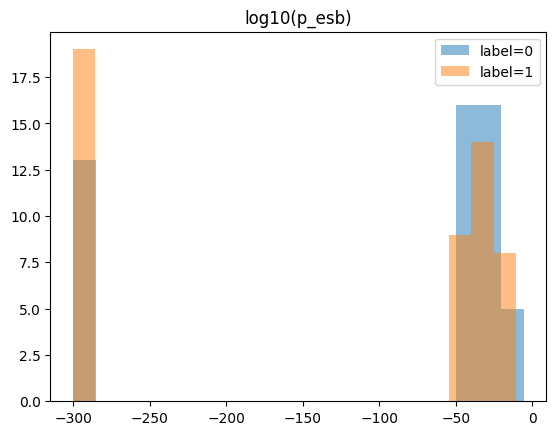

In [6]:
import numpy as np

df["log_p_esb"] = np.log10(
    np.maximum(df["p_esb"], 1e-300)
)

for label in [0,1]:
    subset = df[df.label == label]

    plt.hist(
        subset["log_p_esb"],
        bins=20,
        alpha=0.5,
        label=f"label={label}"
    )

plt.legend()
plt.title("log10(p_esb)")
plt.show()

In [7]:
df.groupby("label")[[
    "run_length",
    "edit_similarity",
    "p_rlb"
]].describe()

run_length                                          edit_similarity  \
           count  mean       std  min  25%  50%  75%  max           count   
label                                                                       
0           50.0  0.70  0.994885  0.0  0.0  0.0  1.0  4.0            50.0   
1           50.0  0.76  0.893514  0.0  0.0  1.0  1.0  3.0            50.0   

                 ...                     p_rlb                                \
           mean  ...       75%       max count      mean       std       min   
label            ...                                                           
0      0.257213  ...  0.277761  0.324818  50.0  0.725848  0.386075  0.000081   
1      0.257800  ...  0.284598  0.328358  50.0  0.629915  0.407955  0.000380   

                                     
            25%       50%  75%  max  
label                                
0      0.451988  1.000000  1.0  1.0  
1      0.206918  0.869365  1.0  1.0  

[2 rows x 24 columns]

In [8]:
df.groupby("label")["p_esb"].median()

label
0    7.669581e-38
1    1.589773e-42
Name: p_esb, dtype: float64

In [9]:
import numpy as np

df["log_p_esb"] = np.log10(
    np.maximum(df["p_esb"], 1e-300)
)

df.groupby("label")["log_p_esb"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,50.0,-101.744151,118.992552,-300.0,-236.213367,-37.117026,-28.465922,-5.416539
1,50.0,-133.967615,131.525798,-300.0,-300.000000,-42.044096,-31.486883,-10.812827
